# Ch4 數位控制器與延遲(Delay in Digital Controllers)

**對應原書**:Chapter 4
**軟體替代**:ModelQ 的數位方塊 + 示波器 → `DiscretePID` 逐樣本模擬 + 解析相位損失公式

## 學習目標
1. 理解數位控制的兩個延遲來源:**ZOH(半個取樣週期)** 與 **計算延遲(最多一個週期)**。
2. 量化延遲對相位邊限的侵蝕:$\Delta\phi = 360° \cdot f_c \cdot T_{delay}$。
3. 觀察取樣率不足時的振鈴與不穩定。

## 理論重點
- 延遲不改變增益,只吃相位 —— Bode 圖上震級不變、相位直線下墜。
- 經驗法則:取樣頻率至少為迴路頻寬的 **20 倍以上**,延遲相位損失才可忽略(< 27°)。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

In [2]:
J, b = 0.002, 0.01
P = inertia(J=J, b=b)
C = pi(kp=0.5, ki=5.0)
m0 = margins(C * P)
fc = m0['f_pm_hz']
print(f"連續系統:PM={m0['pm_deg']:.1f}° @ fc={fc:.1f} Hz")

fs_list = [500, 1000, 2000, 5000, 20000]
rows = []
for fs in fs_list:
    Tdelay = 1.5 / fs                      # ZOH 0.5T + 計算 1T
    loss = 360.0 * fc * Tdelay
    rows.append((fs, loss, m0['pm_deg'] - loss))
print(f"{'fs [Hz]':>8} {'相位損失[°]':>10} {'數位 PM[°]':>10}")
for fs, loss, pm in rows:
    print(f'{fs:>8} {loss:>12.1f} {pm:>12.1f}')

連續系統:PM=88.9° @ fc=39.8 Hz
 fs [Hz]    相位損失[°]   數位 PM[°]
     500         43.0         45.9
    1000         21.5         67.4
    2000         10.7         78.1
    5000          4.3         84.6
   20000          1.1         87.8


## 時域驗證:同一組增益、不同取樣率

理論說 500 Hz 時 PM 只剩 ~45°,5 kHz 時幾乎不變。跑逐樣本模擬對照。

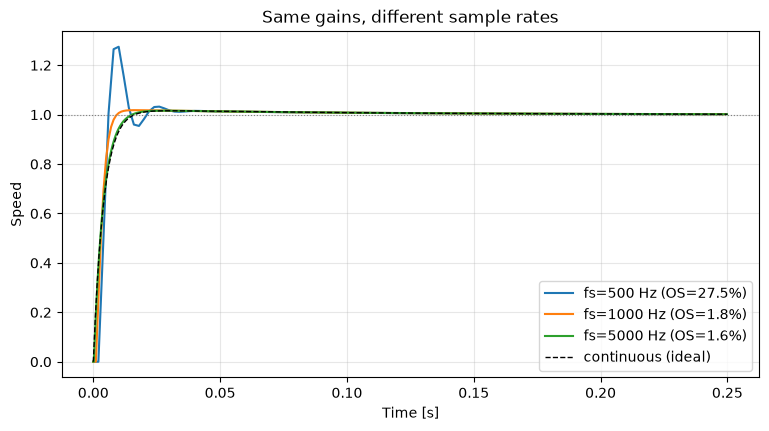

overshoot by fs: {500: 27.5, 1000: 1.8, 5000: 1.6}


In [3]:
plt.figure(figsize=(9, 4.5))
os_by_fs = {}
for fs in [500, 1000, 5000]:
    dt = 1 / fs
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=0.5, ki=5.0, dt=dt)
    delay = Delay(1)                       # 計算延遲:一拍
    n = int(0.25 / dt)
    y = np.empty(n)
    for k in range(n):
        y[k] = plant.w
        u = delay.step(ctrl.step(1.0 - plant.w))
        plant.step(u)
    t = np.arange(n) * dt
    os_by_fs[fs] = step_metrics(t, y)['overshoot_pct']
    plt.plot(t, y, label=f'fs={fs} Hz (OS={os_by_fs[fs]:.1f}%)')

# 連續(理想)響應
T_ideal = closed_loop(C, P)
ti, yi = ct.step_response(T_ideal, np.linspace(0, 0.25, 1000))
plt.plot(ti, yi, 'k--', lw=1, label='continuous (ideal)')
plt.axhline(1, color='gray', ls=':', lw=0.8)
plt.xlabel('Time [s]'); plt.ylabel('Speed'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Same gains, different sample rates')
plt.show()
print('overshoot by fs:', {k: round(v, 1) for k, v in os_by_fs.items()})

## 延遲的 Bode 視角

用二階 Padé 近似把 $e^{-sT_{delay}}$ 放進迴路,直接看 PM 被吃掉。

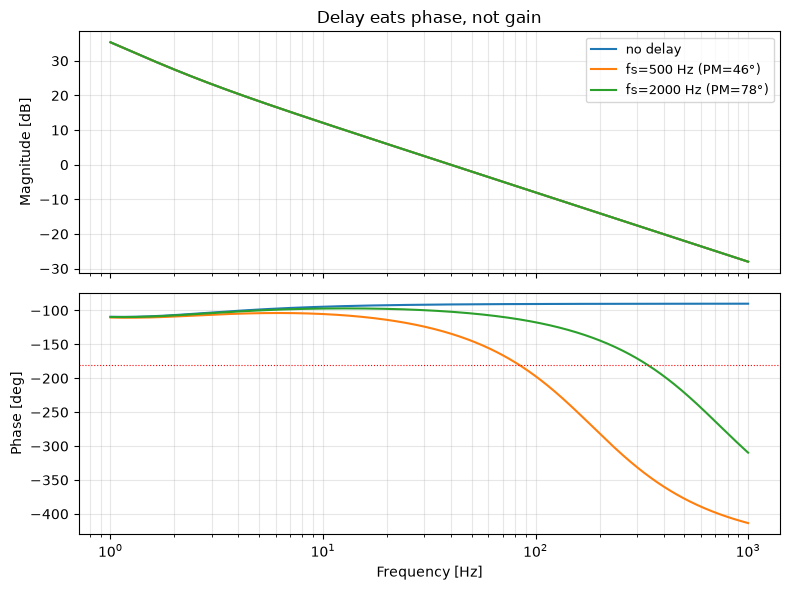

In [4]:
f = np.logspace(0, 3, 500)
items = [('no delay', C * P)]
pm_pade = {}
for fs in [500, 2000]:
    num, den = ct.pade(1.5 / fs, 2)
    Ld = C * P * ct.tf(num, den)
    pm_pade[fs] = margins(Ld)['pm_deg']
    items.append((f'fs={fs} Hz (PM={pm_pade[fs]:.0f}°)', Ld))
fig, (axm, axp) = bode_compare(items, f_hz=f, title='Delay eats phase, not gain')
axp.axhline(-180, color='r', ls=':', lw=0.8)
plt.show()

In [5]:
# ✅ 驗證
assert os_by_fs[500] > os_by_fs[1000] > os_by_fs[5000]   # 取樣率越低振鈴越大
theory = dict((fs, pm) for fs, _, pm in rows)
assert abs(pm_pade[500] - theory[500]) < 6               # Padé vs 直線公式一致
assert abs(pm_pade[2000] - theory[2000]) < 6
assert os_by_fs[5000] < 8                                # 高取樣率接近連續
print('Ch4 驗證通過 ✅')

Ch4 驗證通過 ✅


## 練習
1. 把計算延遲改成 2 拍(`Delay(2)`),500 Hz 的迴路還穩定嗎?
2. 求出讓 PM 恰好剩 30° 的最低取樣率(解析 + 模擬雙重驗證)。
3. 若把 kp 減半,低取樣率的振鈴會改善多少?代價是什麼?
4. 用 DSA(第 2 章方法)量測 fs=500 的閉迴路 FRF,找出峰值頻率。